# Section 1 — Load Data
This notebook studies how three stopping conditions affect a decision tree on the processed Breast Cancer dataset. The goal is to see which condition reduces overfitting most effectively while preserving test accuracy.

In [14]:
import numpy as np
import sys , os
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.join(os.getcwd(),'..','src'))

from decision_trees import DecisionTree
from utils import accuracy, print_tree

X_train = np.load('../Data/processed/bc_X_train.npy')
X_test = np.load('../Data/processed/bc_X_test.npy')
y_train = np.load('../Data/processed/bc_y_train.npy')
y_test = np.load('../Data/processed/bc_y_test.npy') 
feature_names = [f'feature[{i}]' for i in range(X_train.shape[1])]

# Section 2 — Effect of max_depth
max_depth limits how many levels the tree can grow. Small depth means a simple model with high bias; large depth lets the tree fit very specific patterns, which can increase variance and lead to memorization.

In [15]:
rows = []
for d in range(1, 16):
    m = DecisionTree(criterion='gini', max_depth=d, task='classification')
    m.fit(X_train, y_train)
    rows.append({
        'depth': d,
        'train_acc': accuracy(y_train, m.predict(X_train)),
        'test_acc': accuracy(y_test, m.predict(X_test))
    })

df_depth = pd.DataFrame(rows)
print(df_depth.to_markdown(index=False))

|   depth |   train_acc |   test_acc |
|--------:|------------:|-----------:|
|       1 |    0.920879 |   0.894737 |
|       2 |    0.92967  |   0.929825 |
|       3 |    0.978022 |   0.938596 |
|       4 |    0.995604 |   0.938596 |
|       5 |    0.995604 |   0.938596 |
|       6 |    0.997802 |   0.938596 |
|       7 |    1        |   0.938596 |
|       8 |    1        |   0.938596 |
|       9 |    1        |   0.938596 |
|      10 |    1        |   0.938596 |
|      11 |    1        |   0.938596 |
|      12 |    1        |   0.938596 |
|      13 |    1        |   0.938596 |
|      14 |    1        |   0.938596 |
|      15 |    1        |   0.938596 |


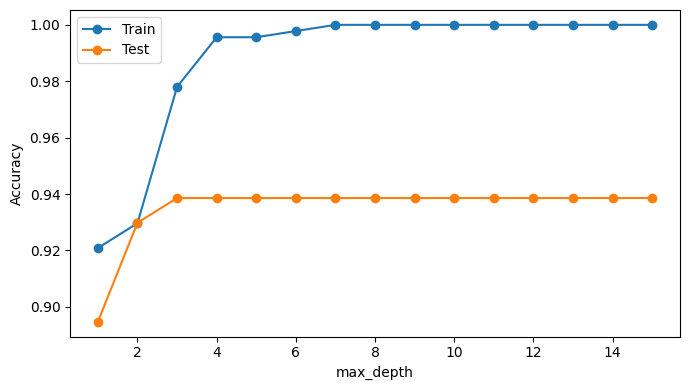

In [16]:
plt.figure(figsize=(7, 4))
plt.plot(df_depth['depth'], df_depth['train_acc'], marker='o', label='Train')
plt.plot(df_depth['depth'], df_depth['test_acc'], marker='o', label='Test')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Section 3 — Effect of min_samples_split
min_samples_split requires a node to contain at least a certain number of samples before it can split. Increasing it makes the tree more conservative, because small noisy groups can no longer branch into separate rules.

In [17]:
rows = []
for s in [2, 5, 10, 20, 50, 100]:
    m = DecisionTree(criterion='gini', max_depth=10, min_samples_split=s, task='classification')
    m.fit(X_train, y_train)
    rows.append({
        'min_samples_split': s,
        'train_acc': accuracy(y_train, m.predict(X_train)),
        'test_acc': accuracy(y_test, m.predict(X_test))
    })

df_split = pd.DataFrame(rows)
print(df_split.to_markdown(index=False))

|   min_samples_split |   train_acc |   test_acc |
|--------------------:|------------:|-----------:|
|                   2 |    1        |   0.938596 |
|                   5 |    0.997802 |   0.938596 |
|                  10 |    0.995604 |   0.938596 |
|                  20 |    0.975824 |   0.938596 |
|                  50 |    0.938462 |   0.912281 |
|                 100 |    0.938462 |   0.912281 |


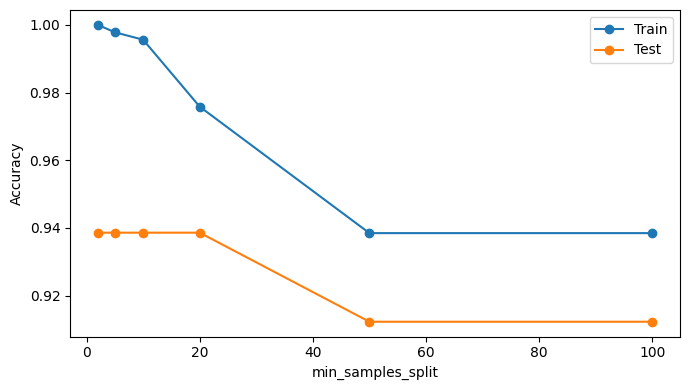

In [18]:
plt.figure(figsize=(7, 4))
plt.plot(df_split['min_samples_split'], df_split['train_acc'], marker='o', label='Train')
plt.plot(df_split['min_samples_split'], df_split['test_acc'], marker='o', label='Test')
plt.xlabel('min_samples_split')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Section 4 — Effect of min_impurity_decrease
min_impurity_decrease sets a minimum quality threshold for a split. A split is only allowed if it reduces impurity by at least that amount. This directly blocks weak, low-value splits and can prevent the tree from chasing noise.`

In [19]:
rows = []
for mid in [0.0, 0.001, 0.005, 0.01, 0.02, 0.05]:
    m = DecisionTree(
        criterion='gini',
        max_depth=10,
        min_samples_split=2,
        min_impurity_decrease=mid,
        task='classification'
    )
    m.fit(X_train, y_train)
    rows.append({
        'min_impurity_decrease': mid,
        'train_acc': accuracy(y_train, m.predict(X_train)),
        'test_acc': accuracy(y_test, m.predict(X_test))
    })

df_imp = pd.DataFrame(rows)
print(df_imp.to_markdown(index=False)) 

|   min_impurity_decrease |   train_acc |   test_acc |
|------------------------:|------------:|-----------:|
|                   0     |    1        |   0.938596 |
|                   0.001 |    0.997802 |   0.938596 |
|                   0.005 |    0.995604 |   0.938596 |
|                   0.01  |    0.989011 |   0.95614  |
|                   0.02  |    0.989011 |   0.95614  |
|                   0.05  |    0.96044  |   0.938596 |


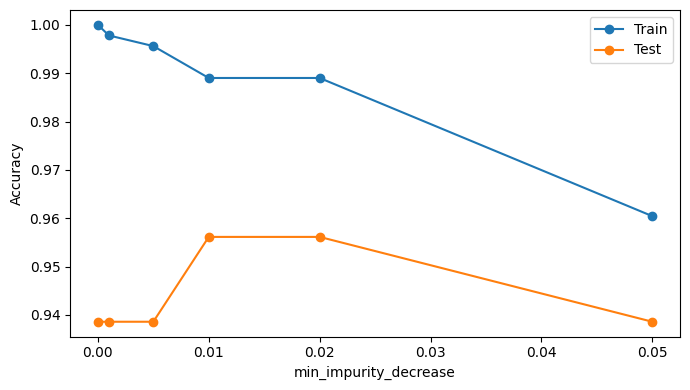

In [20]:
plt.figure(figsize=(7, 4))
plt.plot(df_imp['min_impurity_decrease'], df_imp['train_acc'], marker='o', label='Train')
plt.plot(df_imp['min_impurity_decrease'], df_imp['test_acc'], marker='o', label='Test')
plt.xlabel('min_impurity_decrease')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show() 

# Section 5 — Interaction Study
This section combines the best values from the three earlier studies. The comparison below makes it clear whether combining stopping conditions helps more than using only a depth limit.

In [21]:
best_depth = int(df_depth.loc[df_depth['test_acc'].idxmax(), 'depth'])
best_split = int(df_split.loc[df_split['test_acc'].idxmax(), 'min_samples_split'])
best_mid = float(df_imp.loc[df_imp['test_acc'].idxmax(), 'min_impurity_decrease'])

baseline = DecisionTree(criterion='gini', max_depth=10, task='classification')
baseline.fit(X_train, y_train)
baseline_acc = accuracy(y_test, baseline.predict(X_test))

final_model = DecisionTree(
    criterion='gini',
    max_depth=best_depth,
    min_samples_split=best_split,
    min_impurity_decrease=best_mid,
    task='classification'
)
final_model.fit(X_train, y_train)
final_acc = accuracy(y_test, final_model.predict(X_test))

print('Best max_depth:', best_depth)
print('Best min_samples_split:', best_split)
print('Best min_impurity_decrease:', best_mid)
print('Baseline test accuracy:', baseline_acc)
print('Final combined model test accuracy:', final_acc) 

Best max_depth: 3
Best min_samples_split: 2
Best min_impurity_decrease: 0.01
Baseline test accuracy: 0.9385964912280702
Final combined model test accuracy: 0.9473684210526315
